In [ ]:
import pandas as pd

# '..' moves up to the project root, then we look inside 'data'
file_path = "../data/311-service-requests-from-2010-to-present.csv"
df = pd.read_csv(file_path,nrows=50000)

In [ ]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,45050101,2019-12-01T02:04:01.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,10001.0,WEST 29 STREET,...,NaN,NaN,40.745668,-73.987719,"{'longitude': '-73.9877188309367', 'latitude':...",NaN,NaN,NaN,NaN,NaN
1,45054936,2019-12-01T01:59:41.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11223.0,178 AVENUE U,...,NaN,NaN,40.596475,-73.977721,"{'longitude': '-73.97772147626671', 'latitude'...",NaN,NaN,NaN,NaN,NaN
2,45049329,2019-12-01T01:59:08.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11207.0,807 SCHENCK AVENUE,...,NaN,NaN,40.660605,-73.883508,"{'longitude': '-73.8835082736363', 'latitude':...",NaN,NaN,NaN,NaN,NaN
3,45052046,2019-12-01T01:58:23.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11358.0,42-41 159 STREET,...,NaN,NaN,40.759994,-73.806856,"{'longitude': '-73.80685560533585', 'latitude'...",NaN,NaN,NaN,NaN,NaN
4,45054999,2019-12-01T01:58:07.000,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11426.0,88-49 237 STREET,...,NaN,NaN,40.729499,-73.729998,"{'longitude': '-73.72999847973517', 'latitude'...",NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd

cols = [
    'Complaint Type',
    'Descriptor',
    'Agency',
    'Agency Name'

]

df_small = df[cols]
print(df_small.head())

        Complaint Type                    Descriptor Agency  \
0     Street Condition                       Pothole    DOT   
1   Noise - Commercial              Loud Music/Party   NYPD   
2  Noise - Residential              Loud Music/Party   NYPD   
3  Noise - Residential              Loud Music/Party   NYPD   
4      Illegal Parking  Commercial Overnight Parking   NYPD   

                       Agency Name  
0     Department of Transportation  
1  New York City Police Department  
2  New York City Police Department  
3  New York City Police Department  
4  New York City Police Department  


In [ ]:
print(df_small.isnull().sum())

Complaint Type       0
Descriptor        1141
Agency               0
Agency Name          0
dtype: int64


In [ ]:
df_small['Descriptor'] = df_small['Descriptor'].fillna('')

C:\Users\DELL\AppData\Local\Temp\ipykernel_284\2549098724.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['Descriptor'] = df_small['Descriptor'].fillna('')


In [ ]:
print(df_small.isnull().sum())

Complaint Type    0
Descriptor        0
Agency            0
Agency Name       0
dtype: int64


In [ ]:
df_small['text'] = (
    df_small['Complaint Type'].astype(str)
    + ' '
    +df_small['Descriptor'].astype(str)
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_284\2583074561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['text'] = (


In [ ]:
df_small[['text','Agency']].head()

,text,Agency
0,Street Condition Pothole,DOT
1,Noise - Commercial Loud Music/Party,NYPD
2,Noise - Residential Loud Music/Party,NYPD
3,Noise - Residential Loud Music/Party,NYPD
4,Illegal Parking Commercial Overnight Parking,NYPD


In [ ]:
print(df_small['Agency'].value_counts().head(20))

Agency
NYPD     22207
HPD      10079
DOT       4990
DEP       3812
DSNY      2353
DOB       2134
DOHMH     1181
DPR       1107
TLC        995
DHS        659
DCA        250
EDC        213
DOITT       11
DOE          9
Name: count, dtype: int64


In [ ]:
df_small['Agency'].value_counts

<bound method IndexOpsMixin.value_counts of 0         DOT
1        NYPD
2        NYPD
3        NYPD
4        NYPD
         ... 
49995     HPD
49996     TLC
49997     HPD
49998     HPD
49999     DOT
Name: Agency, Length: 50000, dtype: object>

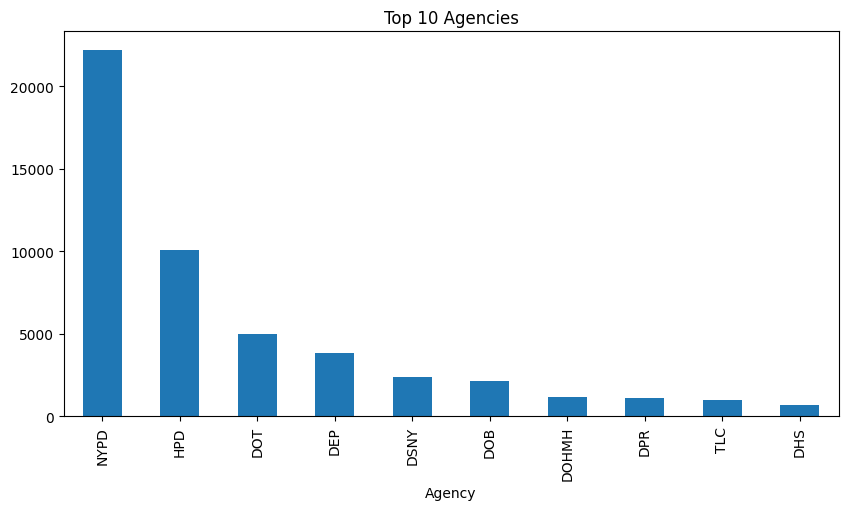

In [ ]:
import matplotlib.pyplot as plt

df_small['Agency'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Agencies")
plt.show()

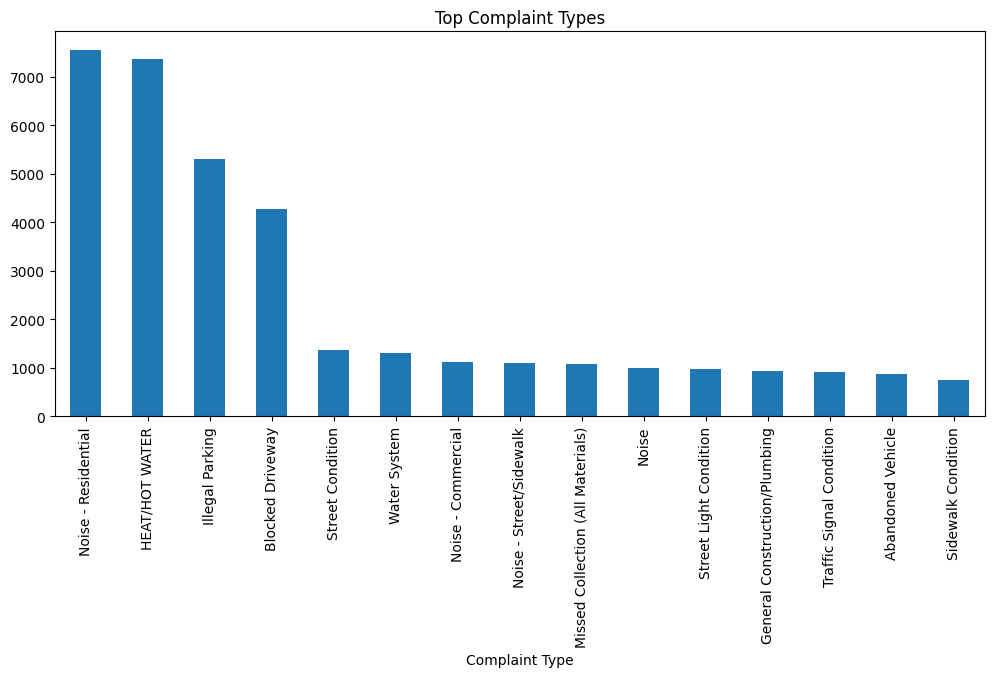

In [ ]:
df_small['Complaint Type'].value_counts().head(15).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top Complaint Types")
plt.show()

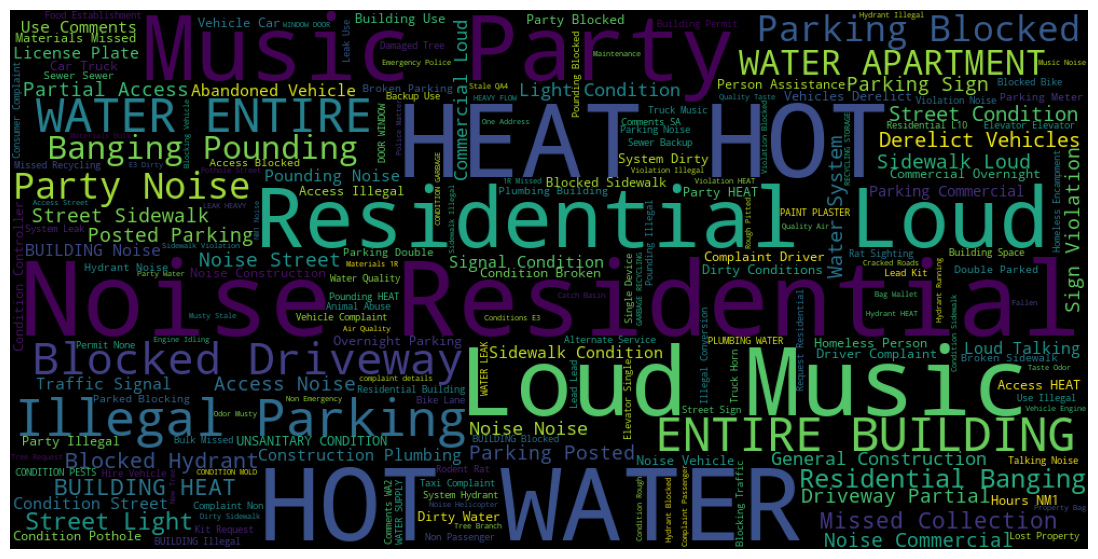

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df_small['text'])

wc = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [ ]:
#Text Cleaning  

df_small[['text','clean_text']].head()
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
df_small['clean_text'] = df_small['text'].apply(clean_text)

df_small[['text','clean_text']].head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_284\3848744621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['clean_text'] = df_small['text'].apply(clean_text)


,text,clean_text
0,Street Condition Pothole,street condition pothole
1,Noise - Commercial Loud Music/Party,noise commercial loud musicparty
2,Noise - Residential Loud Music/Party,noise residential loud musicparty
3,Noise - Residential Loud Music/Party,noise residential loud musicparty
4,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking


In [ ]:
print(df_small.isnull().sum())
print(df_small['Agency'].value_counts().head(20))

Complaint Type    0
Descriptor        0
Agency            0
Agency Name       0
text              0
clean_text        0
dtype: int64
Agency
NYPD     22207
HPD      10079
DOT       4990
DEP       3812
DSNY      2353
DOB       2134
DOHMH     1181
DPR       1107
TLC        995
DHS        659
DCA        250
EDC        213
DOITT       11
DOE          9
Name: count, dtype: int64


In [ ]:
#Remove Very Small Agencies
agency_counts = df_small['Agency'].value_counts()

valid_agencies = agency_counts[agency_counts >= 100].index

df_filtered = df_small[
    df_small['Agency'].isin(valid_agencies)
]

print(df_filtered['Agency'].value_counts())

Agency
NYPD     22207
HPD      10079
DOT       4990
DEP       3812
DSNY      2353
DOB       2134
DOHMH     1181
DPR       1107
TLC        995
DHS        659
DCA        250
EDC        213
Name: count, dtype: int64


In [ ]:
df_filtered.to_csv(
    'final_cleaned_grievances.csv',
    index=False
)